[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SwissChardLeaf/icrn/blob/main/docs/tutorials/getting_started.ipynb)
[![View on GitHub](https://img.shields.io/badge/source-GitHub-blue?logo=github)](https://github.com/SwissChardLeaf/icrn/blob/main/docs/tutorials/getting_started.ipynb)

Getting Started with icrn
=========================

icrn is a python library for the tensor-based and differential simulation of [indexed chemical reaction networks](https://doi.org/10.4230/LIPIcs.DNA.31.4).

# Installing icrn

icrn is registered on PyPi and can be installed using pip.

In [ ]:
!uv pip install icrn

Using Python 3.12.11 environment at: /usr
Audited 1 package in 222ms


Confirm that the installation was successful.

In [ ]:
!uv pip show icrn

Using Python 3.12.11 environment at: /usr
Name: icrn
Version: 0.0.0a0
Location: /usr/local/lib/python3.12/dist-packages
Requires:
Required-by:


# Simulating Your First ICRN

An indexed chemical reaction network (ICRN) is composed of chemical species and rate constants related by index symbols. An ICRN can be built programmatically from analogous building blocks. Notice that the index symbols have an associated parameter that specifies the index set. Currently, the index symbols have index sets {0...n-1}, where n can be specified as an input to an index symbol constructor.

In [ ]:
from icrn import many_index_symbols, many_rate_constants, many_species

In [ ]:
A, B = many_species("A, B")
alpha = many_rate_constants("alpha")
i, j = many_index_symbols("i, j", 5)

The parameters to a mass action reaction constructor are reactant, product, and rate constant information, respectively.

In [ ]:
from icrn import ICRN, MassActionReaction

rxn = MassActionReaction

In [ ]:
example_icrn = ICRN(
    [
        rxn(
            0,  # no reactant
            A[i],  # product is the species A indexed by i
            alpha[i],  # rate constant alpha, also indexed by i
        ),
        rxn(
            A[j],  # reactant A indexed by j
            0,  # no product
            1,  # constant rate of 1
        ),
    ]
)

The icrn can be simulated by creating an Experiment instance with the parameters of interest. The Experiment prepares the functions necessary for simulation using information from the ICRN and the parameters.

In [ ]:
from icrn import Experiment

In [ ]:
exp_params = {
    "dt": 1e-4,  # dt used for integration method
    "batch": False,  # tensors will not have a leading batch dimension
    "integration_method": "euler",  # forward euler integration
    "spatial_dim": None,  # well-mixed simulation
}

exp = Experiment(example_icrn, exp_params)

compiling forward step function...
generating dynamics expressions
separating reactions by timescale
unifying
standardizing
unifying
standardizing
lambdifying expressions
no fast reactions
well-mixed, unbatched
done!


Before we begin simulating, we need to specify initial concentrations of the species and the values of the rate constant. The shapes of the concentrations for the species and the rate constant values are implied by the association of index symbols.

For example, A[i] implies that the shape of A is (5) because the index set associated with i is {0,...,4}.

The concentrations and rate constant values can be manually specified using SJDicts (wrappers to python dictionaries offering convenient functionality). The concentrations and rate constant values should be in JAX arrays.

In [ ]:
import jax.numpy as jnp

from icrn import SJDict

In [ ]:
conc_data = SJDict({A: jnp.ones(5)})

rate_constant_data = SJDict(
    {  # convert python dict into SJDict
        alpha: 1 + jnp.arange(5)
    }
)

print(conc_data)
print(rate_constant_data)

{A: Array([1., 1., 1., 1., 1.], dtype=float32)}
{alpha: Array([1, 2, 3, 4, 5], dtype=int32)}


Or, concentrations and rate constant values can be specified using the dict_builder method which will use the ICRN and broadcasting to create JAX arrays of the correct shape.  Notice that the result of the previous step and this
step are the same.

In [ ]:
concs_spec = {A: 1}

rate_spec = {alpha: 1 + jnp.arange(5)}

# empty dict given as the final parameter is for diffusion rate,
# which is irrelevant in a well-mixed simulation
# we'll talk about that in more detail in a separate tutorial
conc_data, rate_constant_data, _ = exp.dict_builder(concs_spec, rate_spec, {})

print(conc_data)
print(rate_constant_data)

{A: Array([1, 1, 1, 1, 1], dtype=int32, weak_type=True)}
{alpha: Array([1, 2, 3, 4, 5], dtype=int32)}


Now, we can simulate the system for 10 units of time, taking 1000 time points.

In [ ]:
# empty dict is for diffusion rate, which is irrelevant in
# a well-mixed simulation
final_concs, concs_hist = exp.simulate_time(
    conc_data, rate_constant_data, {}, 10.0, sample_num=1000
)

As anticipated, the steady state concentration of A is dictated by their production rates, alpha, essentially [1, 2, 3, 4, 5].

In [ ]:
final_concs

{A: Array([1.      , 1.999404, 2.998808, 3.998808, 4.997616], dtype=float32)}

In [ ]:
type(final_concs)

icrn.dict_utils.SJDict

The other output, the history, contains the initial state and the additional 1000 samples. The leading dimension organizes the history.

In [ ]:
type(concs_hist)

icrn.dict_utils.SJDict

In [ ]:
concs_hist[A].shape

(1001, 5)

The history can be plotted using matplotlib. If you're not familiar already
with matplotlib, there are lots of tutorials online, but it's beyond the scope
of this tutorial.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

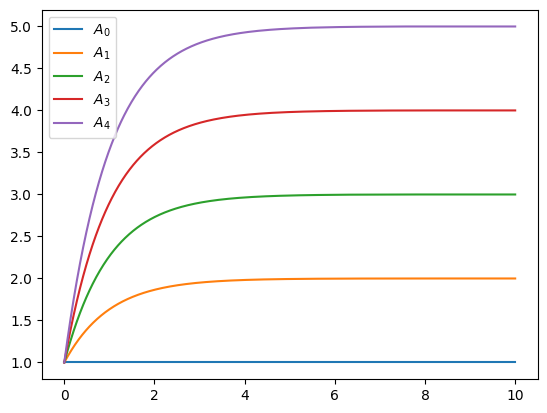

In [ ]:
for i in range(5):
    plt.plot(
        np.arange(0, 1001, 1) * 1e-2, concs_hist[A][..., i], label=f"$A_{i}$"
    )
plt.legend()
plt.show()

# Further Reading

Now you are ready to work with icrn!

Check out the other tutorials for more information.

*   Reaction Diffusion Systems
*   ICRN Numerics
*   Training ICRNs
*   Introduction to SJDicts
*   Profiling Computations

